In [1]:
import pandas as pd
import numpy as np
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load datasets

path = '../dataset/'
train_path = os.path.join(path, 'Train.csv')
test_path = os.path.join(path, 'Test.csv')
gap_train_path = os.path.join(path, 'Gap_Train.csv')
gap_test_path = os.path.join(path, 'Gap_Test.csv')
sample_submission_path = os.path.join(path, 'SampleSubmission.csv')


train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_gap_df = pd.read_csv(gap_train_path)
test_gap_df = pd.read_csv(gap_test_path)
sample_submission = pd.read_csv(sample_submission_path)

In [3]:
# EDA
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7744 entries, 0 to 7743
Data columns (total 44 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         7744 non-null   object 
 1   PID          7744 non-null   object 
 2   lon          7744 non-null   float64
 3   lat          7744 non-null   float64
 4   pH           7744 non-null   float64
 5   alb          7744 non-null   int64  
 6   bio1         7744 non-null   int64  
 7   bio12        7744 non-null   int64  
 8   bio15        7744 non-null   int64  
 9   bio7         7744 non-null   int64  
 10  bp           7744 non-null   float64
 11  cec20        7744 non-null   float64
 12  dows         7744 non-null   float64
 13  ecec20       7739 non-null   float64
 14  hp20         7739 non-null   float64
 15  ls           7744 non-null   float64
 16  lstd         7744 non-null   float64
 17  lstn         7744 non-null   float64
 18  mb1          7744 non-null   float64
 19  mb2   

In [5]:
missing_values = [col for col in train_df.columns if train_df[col].isnull().any()]
print(f"Missing values in train_df: {missing_values}")

Missing values in train_df: ['ecec20', 'hp20', 'xhp20', 'BulkDensity']


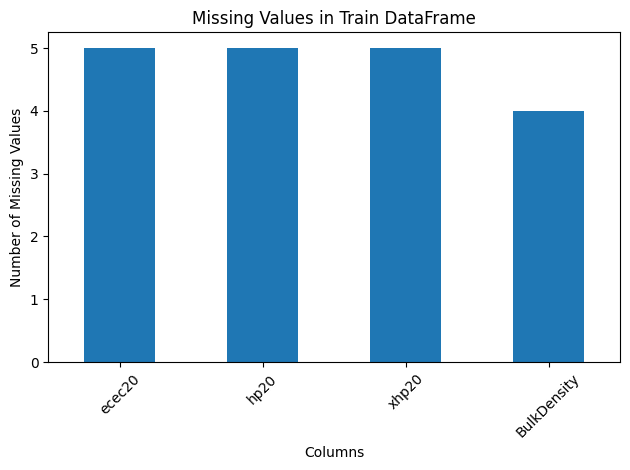

In [6]:
train_df[missing_values].isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values in Train DataFrame')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# To check the data types of the missing values 
missing_data_types = train_df[missing_values].dtypes
print("Data types of missing values:")
print(missing_data_types)



Data types of missing values:
ecec20         float64
hp20           float64
xhp20          float64
BulkDensity    float64
dtype: object


- Since the missing values are all numerical and only a small number is missing we ca use the mean to impute the missing values

In [15]:
# imputing missing values
for col in missing_values:
    train_df[col].fillna(train_df[col].mean(), inplace=True)

missing_values_after = [col for col in train_df.columns if train_df[col].isnull().any()]
print(f"Missing values after imputation: {missing_values_after}")

# Check if there are still missing values

Missing values after imputation: []


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2418 entries, 0 to 2417
Data columns (total 33 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         2418 non-null   object 
 1   PID          2418 non-null   object 
 2   lon          2418 non-null   float64
 3   lat          2418 non-null   float64
 4   pH           2418 non-null   float64
 5   alb          2418 non-null   int64  
 6   bio1         2418 non-null   int64  
 7   bio12        2418 non-null   int64  
 8   bio15        2418 non-null   int64  
 9   bio7         2418 non-null   int64  
 10  bp           2418 non-null   float64
 11  cec20        2418 non-null   float64
 12  dows         2418 non-null   float64
 13  ecec20       2418 non-null   float64
 14  hp20         2418 non-null   float64
 15  ls           2418 non-null   float64
 16  lstd         2418 non-null   float64
 17  lstn         2418 non-null   float64
 18  mb1          2418 non-null   float64
 19  mb2   

In [10]:
# Let's check for missing values in the test set
missing_values_test = [col for col in test_df.columns if test_df[col].isnull().any()]
print(f"Missing values in test_df: {missing_values_test}")


Missing values in test_df: []


The test set has no mising values

### EDA

In [17]:
# Distribution of the columns
def plot_distribution(df, column):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()



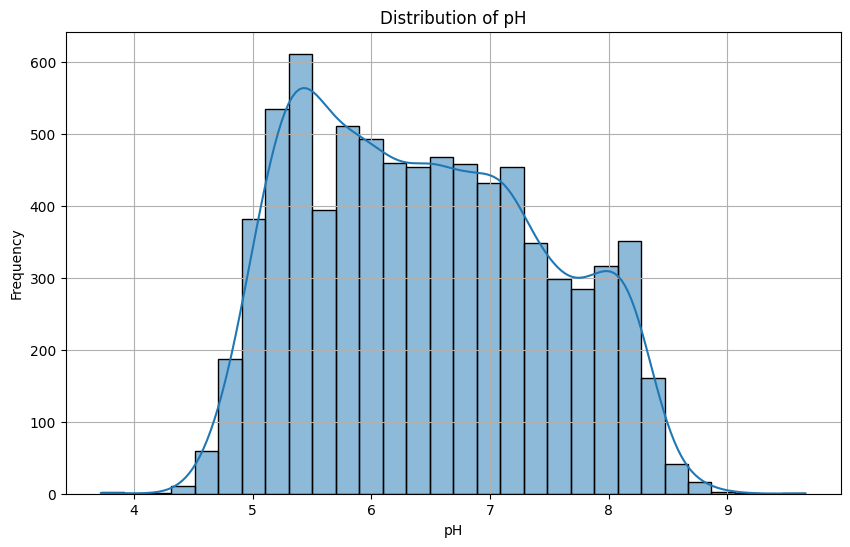

In [18]:
plot_distribution(train_df, 'pH')

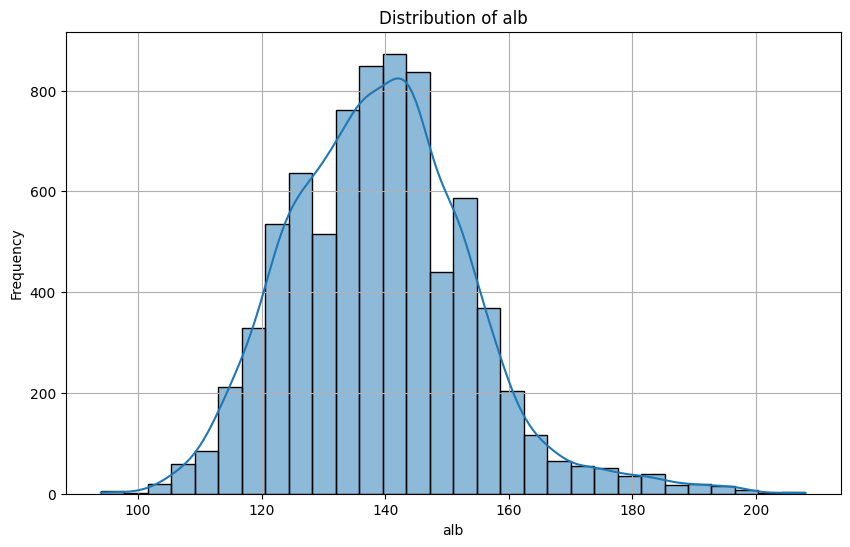

In [20]:
plot_distribution(train_df, 'alb')

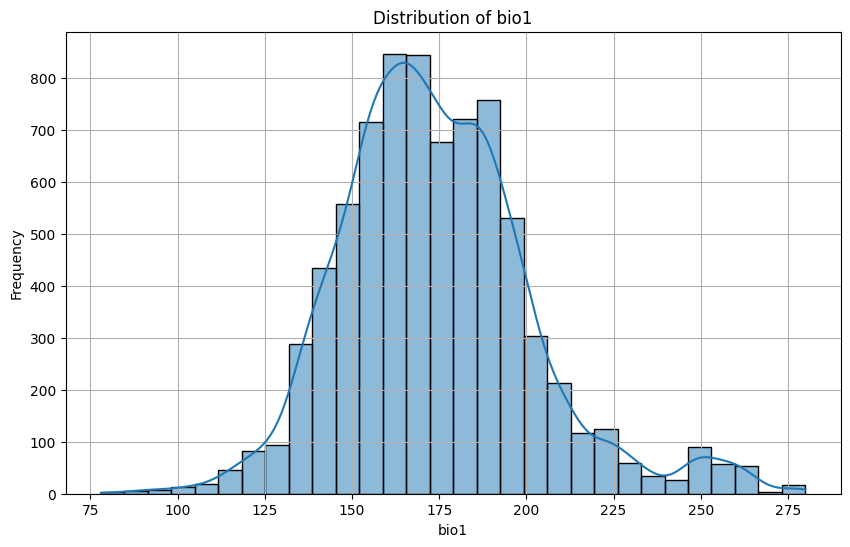

In [21]:
plot_distribution(train_df, 'bio1')

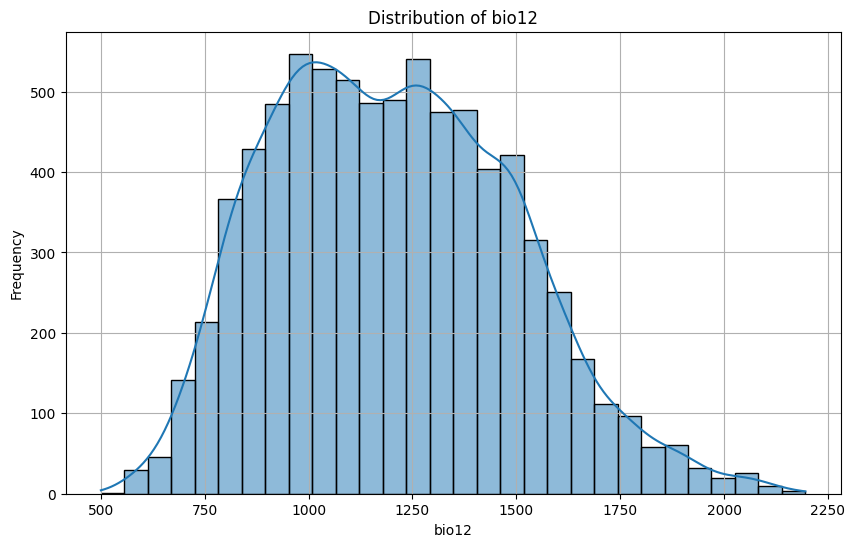

In [22]:
plot_distribution(train_df, 'bio12')

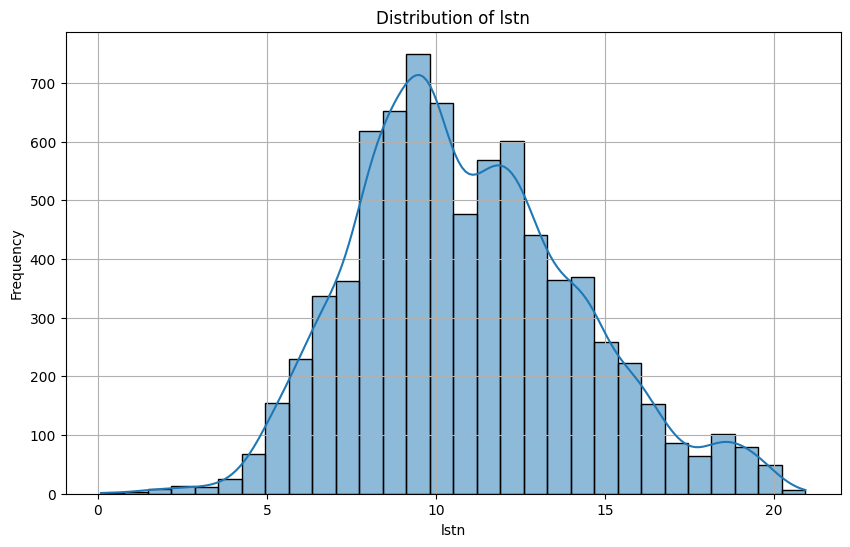

In [24]:
plot_distribution(train_df, 'lstn')